**MDS7203 Modelos Generativos Profundos, Primavera 2023**

# Laboratorio 3: Autoencoders Variacionales

**Profesor**: Felipe Tobar

**Auxiliares**: Cristóbal Alcázar, Camilo Carvajal Reyes.
**Ayudante**: Joaquín Barceló.

## Resumen de preguntas

- [ ] a) (0,5 ptos.) VAE como Modelo Gráfico
- [ ] b) (0.5 ptos.) Truco de reparametrización
- [ ] c) (1 pto.) Encoder en clase VAE
- [ ] d) (1 pto.) Decoder en clase VAE
- [ ] e) (0.5 ptos.) Método _forward_.
- [ ] f) (1 pto.) Términos de la función de costos.
- [ ] g) (0.5 ptos.) Muestreo en espacio latente.
- [ ] h) (1 pto.) VAE condicional.

## Cargar & Visualizar MNIST dataset

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

torch.manual_seed(19_476_309_3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Utilizaremos el emblematico MNIST dataset con imágenes escritas a mano, todas con
dimensión `1 x 28 x 28`. El dataset contiene 60k y 10k de imagenes en blango y negro para entrenamiento y pruebas respectivamente.

In [2]:
batch_size = 128

mnist_dataset = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
loader_train = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)

print(f'Tamaño del trainset: {len(mnist_dataset)} muestras.')

Tamaño del trainset: 60000 muestras.


Observemos las imágenes de un batch de datos con la función `show_batch`.

In [3]:
def show_batch(images, filename=None):
    nrow = int(len(images) ** (1/2))
    grid_tensor = utils.make_grid(images, nrow=nrow)
    plt.axis('off')
    plt.imshow(grid_tensor.permute(1, 2, 0).cpu())
    
    if filename is not None:
        plt.savefig(f'images/{filename}.png', bbox_inches='tight')

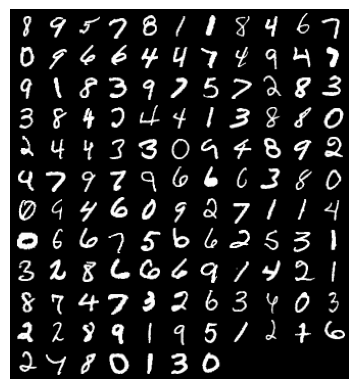

In [4]:
x_batch, y_batch = next(iter(loader_train))
show_batch(x_batch)

## VAE

<img src='https://raw.githubusercontent.com/GAMES-UChile/Curso-Modelos-Generativos-Profundos/main/labs/imgs/vae-gaussian.png' width='600'>

El objetivo de este laboratorio es implementar un Autoencoder Variacional, comprendiendo los 3 elementos principales que conforman su arquitectura, y se pueden ver en el diagrama de arriba que muestra la perspectiva de la red:

1. Encoder Probabilistco
2. Espacio Latente
3. Decoder Probabilistico

Dentro de la primera unidad del curso, estudiamos Graphical Models, por lo que es útil ver la formulación VAE también desde esta perspectiva.

<img src='https://raw.githubusercontent.com/GAMES-UChile/Curso-Modelos-Generativos-Profundos/main/labs/imgs/graphical-model-variational-autoencoder.png' height='200'>

> (a) (0.5 pts) Formule el graphical model para el contexto de VAE.




Un VAE es un modelo generativo de variable latente cuya modelo gráfico asociado es $z\to x$. Es decir, la conjunta se modela mediante $p(x,z)=p(z)p(x|z)$. El factor $p(z)$ (prior de la variable latente) se fija a $\text{NMV}(0,I)$ por conveniencia, mientras que el factor $p(x|z)$ (decoder) se modela como una red neuronal.

Dado que estos modelos siguen el enfoque de máxima verosimilitud, es necesario conocer $p(x)=\frac{p(x,z)}{p(z|x)}$ pero en general, $p(z|x)$ es intratable. Por lo tanto, se agrega un segundo modelo $q(z|x)$ (encoder) que aproxime $p(z|x)$. Este modelo será aprendido por una segunda red neuronal.

## El truco de la reparametrización

Antes de comenzar a ensamblar el modelo, nos detendremos en un paso fundamental, samplear un vector del espacio latente.

Necesitamos que la operación de sampleo sea compatible con el proceso de entrenamiento de la red, es decir, obtener una expresión para $z$ que podamos computar sus derivadas parciales respecto a los parámetros de la distribución que estamos sampleando (e.g. $\mu$, $\sigma$), y así propagar los errores por la red durante el _backward pass_.

Por lo tanto, no podemos samplear $z$ directamente de una $\mathcal{N}(\mu, \sigma)$ usando algo como `torch.normal(mu, sigma, size=(n,))`.

Se requiere implementar el conocido truco de la reparametrización que nos permitirá manejar la estocasticidad del sampling de tal manera que sea posible computar los gradientes del error respecto a nuestra variable latente $z$, así como a los valores de los parámetros empleados usados por la distribución de la que fue sampleada. La siguiente figura ilustra el truco:

<img src='https://raw.githubusercontent.com/GAMES-UChile/Curso-Modelos-Generativos-Profundos/main/labs/imgs/reparameterization-trick.png' width='600'>

Lo que logramos con el truco de la reparametrización es que la estocasticidad es independiente de los parámetros, por lo que nuestra muestra depende deterministicamente de los parámetros de la distribución.

> b) (0.5 pts) Implemente el truco de reparametrización para samplear de una normal dado
mu y logvar.

Se asumirá que la posterior aproximada $q(z|x)$ distribuye como una normal multivariada con matriz de covarianza diagonal. Por lo tanto, sus coordenadas son independientes y pueden generarse individualmente a partir de una gaussiana $\mathcal{N}\left(\mu_i(x),\sigma^2_i(x)\right)$. Por lo tanto, se podrán generar muestras de $q(z|x)$ utilizando `torch.normal`.

In [5]:
def reparameterization_trick(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    '''
    Genera n_samples muestras de la posterior q(z|x) ~ NMV(mu, diag(var)).

    Input:
        - mu[n_samples, latent_size]: medias de cada muestra.
        - logvar[n_samples, latent_size]: log-varianza de cada muestra.

    Returns:
        - z[n_samples, latent_size]: muestras del vector latente.
    '''

    epsilon = torch.normal(mean=torch.zeros_like(mu), std=torch.ones_like(logvar))
    z = mu + torch.exp(logvar * 0.5) * epsilon
    return z

## Fully Connected VAE

Ahora comencemos a construir nuestra red `VAE` fully connected. Esta desginación hace referencia al tipo de arquitectura que emplearemos para las funciones de codificación y decodificación. Usted debera implementar la clase `VAE` que se encuentra al final de esta sección, en particular, debe realizar el siguiente _checklist_.

- [ ] Bloque encoder, o codificador, con la arquiectura feed forward especificada.
- [ ] Capas lineales para los parámetros de la distribución normal que define nuestro espacio latente.
- [ ] Bloque decoder, o decodificador, con la arquitectura feed forward especificada.
- [ ] Método forward para el flujo de operaciones i/o de la red.


Empezaremos con el codificador, que tomará nuestras imágenes como entrada (después de aplanar la forma C,H,W a D) y las pasará a través de tres capas Lineales+ReLU. Usaremos esta representación de dimensión oculta para predecir tanto la media posterior como la log-varianza posterior utilizando dos capas lineales separadas (ambas con forma (N,Z)).

Tenga en cuenta que llamamos a una de las capas 'logvar' porque usaremos la log-varianza (en lugar de la varianza o la desviación estándar) para estabilizar el entrenamiento. Esto explica el nombre de uno de los parámetros de la función `reparameterization_trick` implementada en l sección anterior.


> c) (1 pts) Defina el `encoder`,  `hidden_dim` ($H$),  `mu_layer`, y  `logvar_layer` en la inicialización de la clase VAE. Utilizar las siguientes especificaciones para la arquitectura del `encoder`:
> * Capa fully connected con tamaño de input 784 (`input_size`) y output $H$ (`hidden_dim`)
> * `ReLU`
> * Capa fully connected con tamaño de input $H$ y output $H$
> * `ReLU`
> * Capa fully connected con tamaño de input $H$ y output $H$
> * `ReLU`


Luego, definiremos el decodificador, que toma como input la representación del espacio latente y reconstruye el input (i.e. imagen) a partir de esta representación compacta y probabilistica que buscamos aprender.

> d) (1 pts) Defina el bloque `decoder` con las siguientes especificaciones para su arquitectura:
> * Capa fully connected con tamaño de input igual al del espacio latente $Z$ (`latent_size`) y output $H$ (`hidden_dim`)
> * `ReLU`
> * Capa fully connected con tamaño de input $H$ y output $H$
> * `ReLU`
> * Capa fully connected con tamaño de input $H$ y output $H$
> * `ReLU`
> * Capa fully connected con tamaño de input $H$ y output 784 (`input_size`)
> * `Sigmoid`
> * `Unflatten` para volver a las dimensiones `1 x 28 x 28` originales

> e) (0.5 pts) Complete el método _forward_ de la clase `VAE`. Encargado de (i) pasar la imagen de input por el codificador y calcular las estimaciones para `mu` y `logvar`, luego (ii) usar el `reparameterization_trick`, implementado en la sección anterior, para obtener una estimación del espacio latente. Finalmente, (iii) pasará  esta represetación del espacio latente por el decodificador y generará una nueva imagen.

Dada la estructura de la clase `VAE`, se asumirá que las imágenes tendrán un único canal (monocromáticas).

In [6]:
class VAE(nn.Module):
    '''
    VAE fully-connected.
    '''

    def __init__(self, input_size: int, hidden_dim: int, latent_size: int):
        super(VAE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size
        self.hidden_dim = hidden_dim

        # Encoder:
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            #nn.ReLU() -> no se aplicará para no desactivar códigos negativos.
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_size)
        self.logvar_layer = nn.Linear(hidden_dim, latent_size)

        # Decoder:
        image_width = int(input_size ** (1/2))
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_size),
            nn.Sigmoid(),
            nn.Unflatten(-1, (1, image_width, image_width))
        )

    def forward(self, x: torch.Tensor) -> tuple:
        '''
        Parameters:
            - x[batch_size, channels, height, width]: batch de imágenes.
        
        Returns:
            - x_hat[batch_size, channels, height, width]: batch de probabilidades (por cada pixel).
            - mu[batch_size, latent_size]: tensor con la media de cada z|x.
            - logvar[batch_size, latent_size]: tensor con la log-varianza de cada z|x.
        '''
        
        encoding = self.encoder(x)
        mu, logvar = self.mu_layer(encoding), self.logvar_layer(encoding)
        z = reparameterization_trick(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

Es importante notar que la salida del decoder (que representa a $p(x|z)$) corresponde realmente a una "imagen" cuyos pixeles tienen un valor en $(0,1)$, por lo que implícitamente se está modelando cada pixel como una distribución Bernoulli (donde la intensidad de la imagen es la probabilidad de activación del pixel). La justificación de esto está en el informe de la parte teórica.

Siempre es un buen _sanity check_ que la data fluya correctamente por el modelo.

In [7]:
batch_size, channels, height, width = x_batch.shape
hidden_dim, latent_size = 64, 16

vae = VAE(height * width, hidden_dim, latent_size)
x_hat, mu, logvar = vae(x_batch)

assert x_hat.shape == torch.Size([batch_size, channels, height, width])
assert mu.shape == torch.Size([batch_size, latent_size])
assert logvar.shape == torch.Size([batch_size, latent_size])

El _forward pass_ retorna 3 elementos: la reconstrucción de la imagen, la media posterior y la log-varianza posterior. Estos últimos dos elementos, tal como se vio en la clase y en la pregunta teoríca, serán utilizados para calcular la función de pérdida del modelo.

## Función de pérdida/costo

Recuerde que la función de costo del VAE está compuesta por dos términos: (i) el término de reconstrucción, que mide la diferencia entre la imagen reconstruida y la imagen original, y (ii) el término de divergencia KL, que mide la diferencia entre la distribución posterior y la distribución prior del espacio latente.

$$-\mathbb{E}_{z\sim q_{\phi}(z|x)}[log p_{\theta}(x|z)] + D_{KL}(q_{\phi}(z|x), p(z)))$$

Ten en cuenta que esto es el negativo del límite inferior variacional que se estudio en la clase, lo que asegura que al minimizar este término de pérdida, estamos maximizando el límite inferior variacional. El término de pérdida de reconstrucción se puede calcular simplemente utilizando la pérdida de entropía cruzada binaria entre los píxeles de la entrada original y los píxeles de salida de nuestro decodificador (**Hint:** `F.binary_cross_entropy`). El término de divergencia KL trabaja para forzar que la distribución del espacio latente esté cerca de la distribución prior (estamos utilizando una distribución gaussiana normal estándar como nuestra distribución prior).

Para ayudarte, hemos derivado una forma no vectorizada del término de divergencia KL para ti.
Supongamos que $q_\phi(z|x)$ es una gaussiana diagonal de $Z$ dimensiones con media $\mu_{z|x}$ de forma $(Z,)$ y desviación estándar $\sigma_{z|x}$ de forma $(Z,)$, y que $p(z)$ es una gaussiana de $Z$ dimensiones con media cero y varianza unitaria. Entonces podemos escribir el término de divergencia KL como:

$$D_{KL}(q_{\phi}(z|x), p(z))) = -\frac{1}{2} \sum_{j=1}^{J} (1 + log(\sigma_{z|x}^2)_{j} - (\mu_{z|x})^2_{j} - (\sigma_{z|x})^2_{j})$$

Se debe adaptar a una versión vectorizada que funcione en mini lotes.


> f) (1 pts) Defina los términos `reconstruction_term` y `kl_divergence_term` de la función de costo.

Se sugiere la siguiente discusión sobre [porqué la función de costo a utilizar para el término de reconstrucción es `F.binary_cross_entropy` y no `F.mse_loss`](https://www.reddit.com/r/MachineLearning/comments/4ujr2s/comment/d5qj3m9/?utm_source=share&utm_medium=web2x).

In [8]:
def loss_function(model: nn.Module, x: torch.Tensor, y: torch.Tensor, conditional: bool) -> torch.Tensor:
    y_onehot = F.one_hot(y, num_classes=10)
    x_hat, mu, logvar = model(x, y_onehot) if conditional else model(x)
    reconstruction_term = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    kl_divergence_term = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return reconstruction_term + kl_divergence_term

En el cálculo anterior se utilizó una única muestra $\hat{z}\sim q(z|x)$ para la estimación de Monte Carlo del término de reconstrucción.

Es importante notar que el cálculo anterior considera implicitamente que la verosimilitud condicional $p(x|\hat{z})$ 

## Entrenamiento

In [9]:
def train_vae(model: nn.Module, optimizer: optim.Optimizer, dataloader: DataLoader, epochs: int, conditional: bool = False) -> None:
    
    model.train()
    model.to(device)

    for epoch in range(epochs):
        epoch_loss = 0

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            loss = loss_function(model, x, y, conditional)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        epoch_loss /= len(dataloader)
        print(f'Epoch {epoch+1}/{epochs} | loss: {epoch_loss:.4f}')

In [10]:
hidden_dim, latent_size = 64, 16
epochs = 20

vae = VAE(height * width, hidden_dim, latent_size)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

train_vae(vae, optimizer, loader_train, epochs)

Epoch 1/20 | loss: 212.5764
Epoch 2/20 | loss: 177.4144
Epoch 3/20 | loss: 159.4713
Epoch 4/20 | loss: 146.5218
Epoch 5/20 | loss: 141.1829
Epoch 6/20 | loss: 135.3721
Epoch 7/20 | loss: 131.8968
Epoch 8/20 | loss: 130.0854
Epoch 9/20 | loss: 128.7780
Epoch 10/20 | loss: 127.6823
Epoch 11/20 | loss: 126.7341
Epoch 12/20 | loss: 125.9778
Epoch 13/20 | loss: 125.3403
Epoch 14/20 | loss: 124.7194
Epoch 15/20 | loss: 124.1897
Epoch 16/20 | loss: 123.7150
Epoch 17/20 | loss: 123.2197
Epoch 18/20 | loss: 122.7261
Epoch 19/20 | loss: 122.1752
Epoch 20/20 | loss: 121.6249


## Generando muestras 🎨

Después de entrenar nuestra red VAE, podemos aprovechar su capacidad para generar nuevos ejemplos. Este proceso implica simplemente el decodificador: inicializamos alguna distribución aleatoria para el espacio latente $z$ y generamos los nuevos ejemplos al pasar este vector latente al decodificador.

<img src='https://github.com/GAMES-UChile/Curso-Modelos-Generativos-Profundos/raw/main/labs/imgs/vae_gen_samples.jpg' width='600'>

> g) (0.5 pts) Muestrear del espacio latente aprendido y generar una figura con 10 imágenes como la de arriba. El código para generar la visualización va por cuenta de la casa.

In [11]:
def generate_samples(model: nn.Module, n_samples: int) -> None:

    model.eval()
    z = torch.randn(n_samples, model.latent_size).to(device)
    samples = model.decoder(z)

    show_batch(samples, 'unconditional')

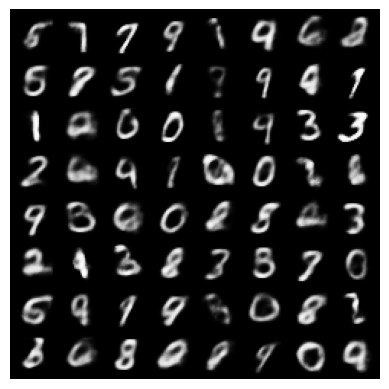

In [12]:
generate_samples(vae, 64)

## Interpolación en el Espacio Latente

Como una prueba visual final de nuestro modelo VAE entrenado, podemos realizar interpolación en el espacio latente. Generamos vectores latentes aleatorios $z_0$ y $z_1$, y realizamos una interpolación lineal entre ellos; luego, ejecutamos cada vector interpolado a través del generador entrenado para producir una imagen.

Cada fila de la figura a continuación interpola entre dos vectores aleatorios. En su mayor parte, el modelo debería mostrar transiciones suaves a lo largo de cada fila, lo que demuestra que el modelo ha aprendido algo no trivial sobre la estructura espacial subyacente de los dígitos que está modelando.


In [13]:
def interpolate_samples(model: nn.Module, latent_size: int, steps: int = 10) -> None:
    
    z0 = torch.randn(steps, latent_size, device=device)
    z1 = torch.randn(steps, latent_size, device=device)
    w = torch.linspace(0, 1, steps, device=device).view(steps, 1, 1)

    z = (w * z0 + (1 - w) * z1).transpose(0, 1).reshape(steps * steps, latent_size)
    x_hat = model.decoder(z)

    show_batch(x_hat, 'interpolation')

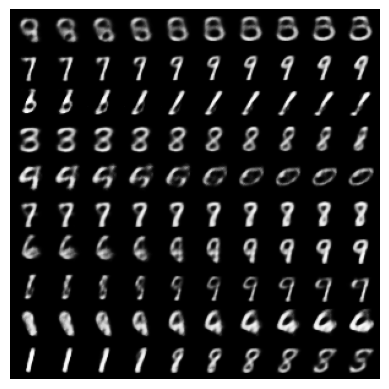

In [14]:
interpolate_samples(vae, latent_size)

## Condicionar el modelo con las etiquetas


En esta última sección, implementaremos el modelo `ConditionalVAE`, una
variante cercana al `VAE`, pero con una condición adicional. Usaremos las etiquetas de las imágenes de MNIST para influir en la generación de imágenes dentro de categorías específicas. En lugar de trabajar solo con $q_{\phi} (z|x)$ y $p_{\phi}(x|z)$, ahora introducimos $q_{\phi} (z|x,c)$ y $p_{\phi}(x|z, c)$.

Esta modificación nos habilita para llevar a cabo generación condicional en la etapa de inferencia. Con ello, podremos elegir crear deliberadamente más 1s, 2s, 9s, y otras clases, en lugar de simplemente generar dígitos aleatorios.

La arquitectura del `ConditionalVAE` seguirá siendo similar a la de la clase `VAE` implementada, pero con una adición importante: incorporaremos un vector de etiquetas one-hot tanto en la entrada $x$ (las dimensiones de la imagen aplanada) como en el espacio latente $z$.

El vector one-hot se denominará 'c', donde 'c[label] = 1' y 'c = 0' en todas las demás ubicaciones.

Estas son las modificaciones a considerar:

1. Ajusta la primera capa lineal del encoder para que no solo reciba la imagen de entrada aplanada, sino también el vector one-hot de etiquetas 'c'.
2. Modifica la primera capa del decoder para proyectar el espacio latente combinado con el vector one-hot a la dimensión 'hidden_dim'.
3. Finalmente, en el paso 'forward', combina la imagen de entrada aplanada con los vectores one-hot (utilizando 'torch.cat') antes de pasarlos al encoder, y fusiona el espacio latente con los vectores one-hot (también con 'torch.cat') antes de enviarlos al decoder.


> h) (1 pts) Implemente la clase `ConditionalVAE` siguiendo las modificaciones indicadas.

In [15]:
class ConditionalVAE(nn.Module):
    '''
    Conditional VAE fully-connected.
    '''

    def __init__(self, input_size: int, hidden_dim: int, latent_size: int, n_classes: int = 10):
        super(ConditionalVAE, self).__init__()

        self.input_size = input_size
        self.latent_size = latent_size
        self.hidden_dim = hidden_dim
        self.n_classes = n_classes

        # Encoder:
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size + n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            #nn.ReLU()
        )

        self.mu_layer = nn.Linear(hidden_dim, latent_size)
        self.logvar_layer = nn.Linear(hidden_dim, latent_size)

        # Decoder:
        self.decoder = nn.Sequential(
            nn.Linear(latent_size + n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_size),
            nn.Sigmoid(),
            nn.Unflatten(-1, (1, int(input_size ** (1/2)), int(input_size ** (1/2))))
        )

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> tuple:
        '''
        Parameters:
            - x[batch_size, channels, height, width]: batch de imágenes.
            - c[batch_size, n_classes]: batch de vectores one-hot.
        
        Returns:
            - x_hat[batch_size, channels, height, width]: batch de probabilidades (por cada pixel).
            - mu[batch_size, latent_size]: tensor con la media de cada z|x,c.
            - logvar[batch_size, latent_size]: tensor con la log-varianza de cada z|x,c.
        '''
        
        x_c = torch.cat([x.flatten(1), c], dim=1)
        encoding = self.encoder(x_c)
        mu, logvar = self.mu_layer(encoding), self.logvar_layer(encoding)
        z = reparameterization_trick(mu, logvar)
        z_c = torch.cat([z, c], dim=1)
        x_hat = self.decoder(z_c)
        
        return x_hat, mu, logvar


Entrenamos usando la misma función `train_vae`, pero con el argumento `conditional=True`.

In [16]:
hidden_dim, latent_size = 64, 16
epochs = 20

conditional_vae = ConditionalVAE(height * width, hidden_dim, latent_size)
conditional_optimizer = optim.Adam(conditional_vae.parameters(), lr=1e-3)

train_vae(conditional_vae, conditional_optimizer, loader_train, epochs, conditional=True)

Epoch 1/20 | loss: 212.0183
Epoch 2/20 | loss: 169.3749
Epoch 3/20 | loss: 146.3232
Epoch 4/20 | loss: 137.7307
Epoch 5/20 | loss: 132.4985
Epoch 6/20 | loss: 128.6302
Epoch 7/20 | loss: 125.8383
Epoch 8/20 | loss: 123.9403
Epoch 9/20 | loss: 122.6497
Epoch 10/20 | loss: 121.5508
Epoch 11/20 | loss: 120.6895
Epoch 12/20 | loss: 119.9246
Epoch 13/20 | loss: 119.2627
Epoch 14/20 | loss: 118.5568
Epoch 15/20 | loss: 118.0799
Epoch 16/20 | loss: 117.5375
Epoch 17/20 | loss: 117.0851
Epoch 18/20 | loss: 116.6636
Epoch 19/20 | loss: 116.2568
Epoch 20/20 | loss: 115.9003


Vamos a generar del 0 al 9 digitos.

In [17]:
def generate_conditional_samples(model: nn.Module, samples_per_class: int = 10):

    model.eval()
    all_samples = []

    with torch.no_grad():
        for i in range(10):
            c = F.one_hot(torch.tensor([i] * samples_per_class), num_classes=10).to(device)
            z = torch.randn(samples_per_class, model.latent_size).to(device)
            samples = model.decoder(torch.cat([z, c], dim=1))
            all_samples.extend(samples)

    show_batch(all_samples, 'conditional')

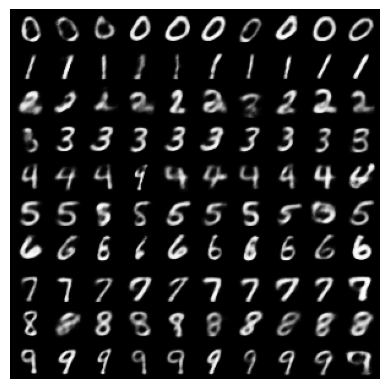

In [18]:
generate_conditional_samples(conditional_vae)

Podemos generar muestras de un número que sea 70% del digito 3 y 30% del digito 7.

In [19]:
def mixed_samples(model: nn.Module, latent_size: int, n_samples: int, alpha: float, digit1: int, digit2: int):

    z = torch.randn(n_samples, latent_size)
    c_mix = torch.zeros(n_samples, 10)
    c_mix[:, digit1] = alpha
    c_mix[:, digit2] = 1 - alpha

    z = torch.cat((z, c_mix), dim=-1).to(device)

    model.eval()
    samples = model.decoder(z)

    show_batch(samples, 'mixed')

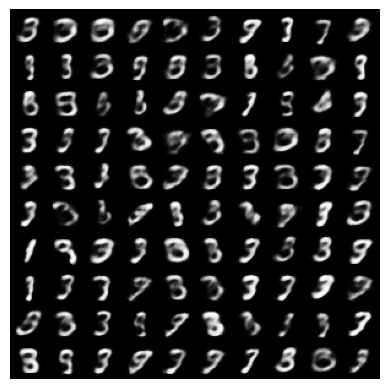

In [20]:
mixed_samples(conditional_vae, latent_size=16, n_samples=100, alpha=0.7, digit1=3, digit2=7)